In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
connection = sqlite3.connect("student.db")

In [6]:
df = pd.read_csv('student_performance.csv')


In [7]:
df.to_sql('students', connection, if_exists='replace', index=False)

30

In [8]:
query1 = """
SELECT department,
AVG(math_score) AS avg_math
FROM students
GROUP BY department
"""

In [9]:
panel1 = pd.read_sql_query(query1, connection)

In [10]:
query2 = """
SELECT department,
COUNT(*) AS student_count
FROM students
GROUP BY department
"""

In [11]:
panel2 = pd.read_sql_query(query2, connection)

In [12]:
query3 = """
SELECT name,
total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

In [14]:
query3_fixed = """
SELECT name,
(math_score + english_score + science_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""
panel3 = pd.read_sql_query(query3_fixed, connection)

In [15]:
query4 = """
SELECT gender,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY gender
"""

panel4 = pd.read_sql_query(query4, connection)

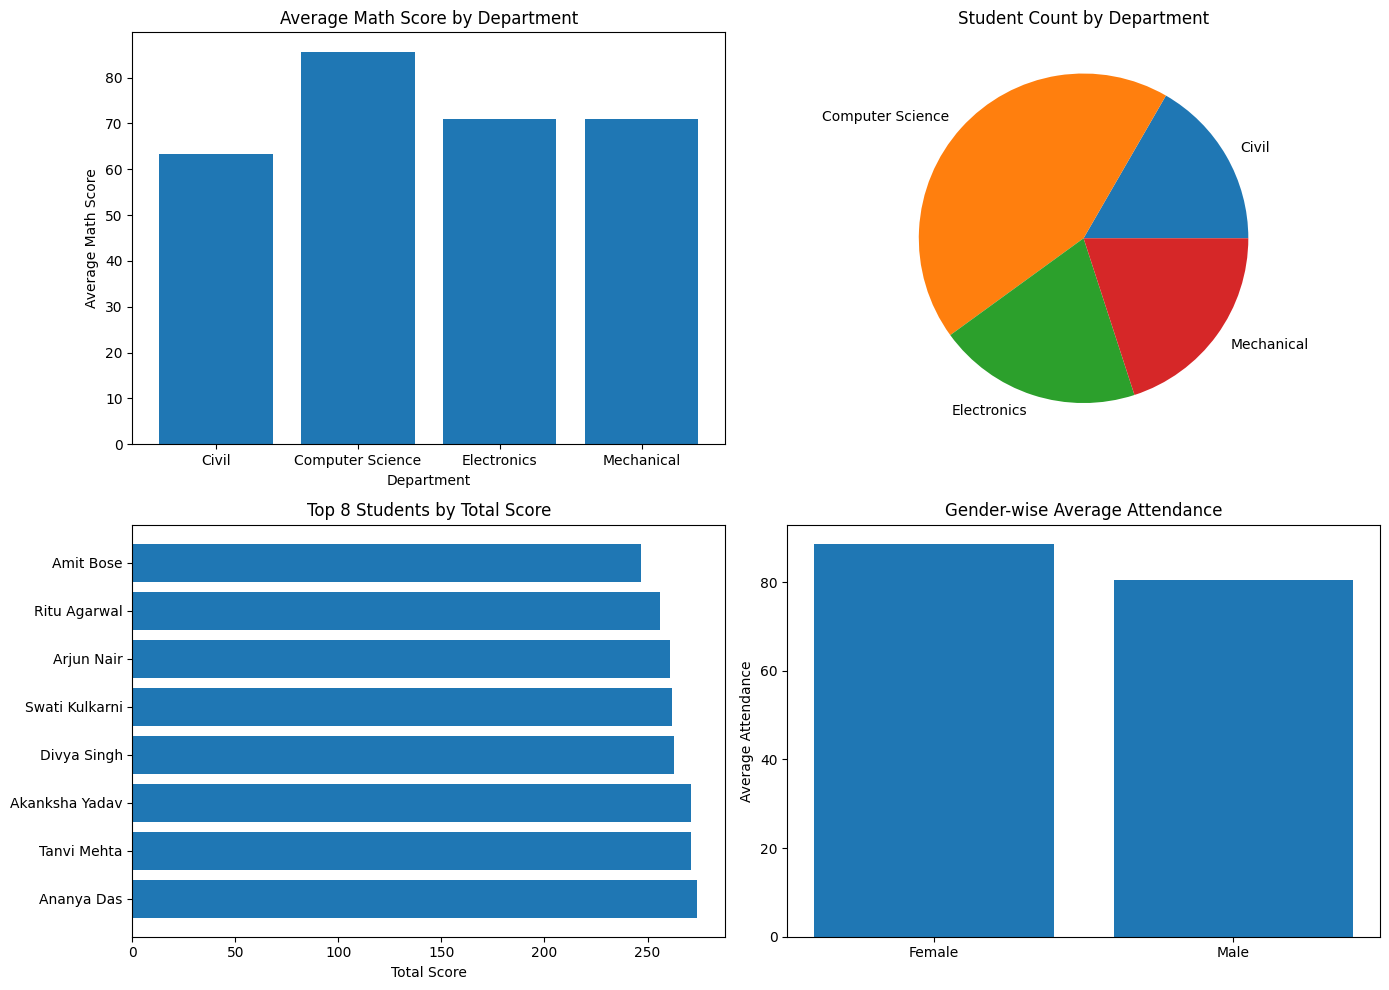

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes[0,0].bar(panel1['department'], panel1['avg_math'])
axes[0,0].set_title("Average Math Score by Department")
axes[0,0].set_xlabel("Department")
axes[0,0].set_ylabel("Average Math Score")

axes[0,1].pie(
    panel2['student_count'],
    labels=panel2['department'],
)
axes[0,1].set_title("Student Count by Department")

axes[1,0].barh(panel3['name'], panel3['total_score'])
axes[1,0].set_title("Top 8 Students by Total Score")
axes[1,0].set_xlabel("Total Score")

axes[1,1].bar(panel4['gender'], panel4['avg_attendance'])
axes[1,1].set_title("Gender-wise Average Attendance")
axes[1,1].set_ylabel("Average Attendance")

plt.tight_layout()
plt.show()
